# Изследователски анализ на данните (EDA II) - Структура и Зависимости
**Проект:** Crypto Anomaly Detection System (CADS)
**Фаза:** Data Understanding & Feature Engineering Analysis
**Автор:** Сергей Топтунов

**Цел на анализа:**
1. Да се създадат първоначални признаци (Features) от суровите данни.
2. Да се изследва корелацията между тях и целевата променлива (Target).
3. Да се провери за "изтичане на информация" (Data Leakage).
4. Да се намали размерността (PCA) за визуализация на клъстери/аномалии.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf

# Настройки
sns.set(style="whitegrid")
SYMBOL = 'BTC-USD'
START = '2020-01-01'

# 1. Зареждане
df = yf.download(SYMBOL, start=START)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Feature Engineering (Създаване на признаци за анализ)
# Целева променлива (Target): Цената на затваряне утре
df['Target_NextClose'] = df['Close'].shift(-1)

# Входни признаци (Features)
df['Lag_1'] = df['Close'].shift(1)  # Вчерашна цена
df['SMA_7'] = df['Close'].rolling(window=7).mean() # Седмичен тренд
df['SMA_30'] = df['Close'].rolling(window=30).mean() # Месечен тренд
df['Volatility'] = df['Close'].rolling(window=7).std() # Риск
df['Daily_Return'] = df['Close'].pct_change() # Моментум
df['RSI_Proxy'] = df['Daily_Return'].rolling(14).mean() # Прост RSI аналог

# Почистване на NaN (от шифтовете)
df.dropna(inplace=True)

print("Данните са подготвени. Брой записи:", len(df))

[*********************100%***********************]  1 of 1 completed

Данните са подготвени. Брой записи: 2199


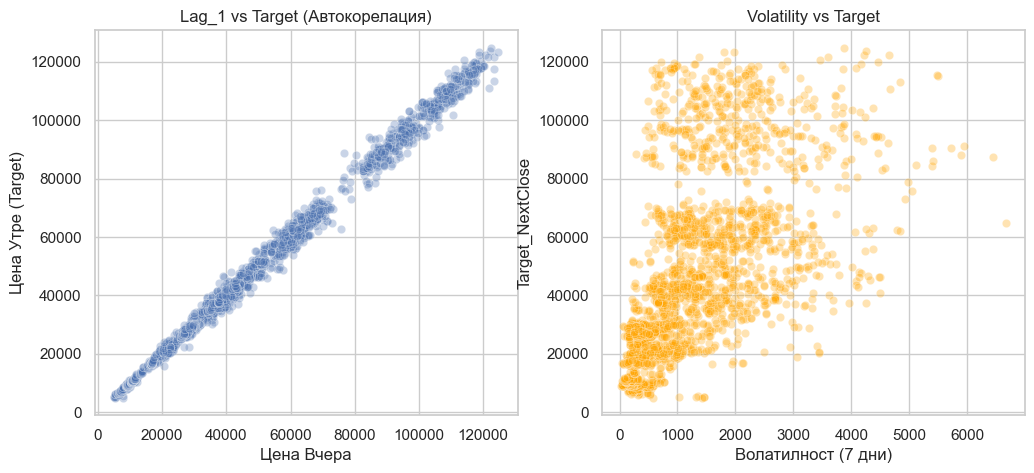

In [15]:
# Изследване на линейната зависимост
plt.figure(figsize=(12, 5))

# Графика 1: Вчерашна цена vs Утрешна цена (Автокорелация)
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['Lag_1'], y=df['Target_NextClose'], alpha=0.3)
plt.title('Lag_1 vs Target (Автокорелация)')
plt.xlabel('Цена Вчера')
plt.ylabel('Цена Утре (Target)')

# Графика 2: Волатилност vs Промяна в цената
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Volatility'], y=df['Target_NextClose'], alpha=0.3, color='orange')
plt.title('Volatility vs Target')
plt.xlabel('Волатилност (7 дни)')
plt.show()

# Извод: Силна линейна зависимост при Lag_1. Слаба линейна зависимост при Волатилността (което предполага нелинейност).

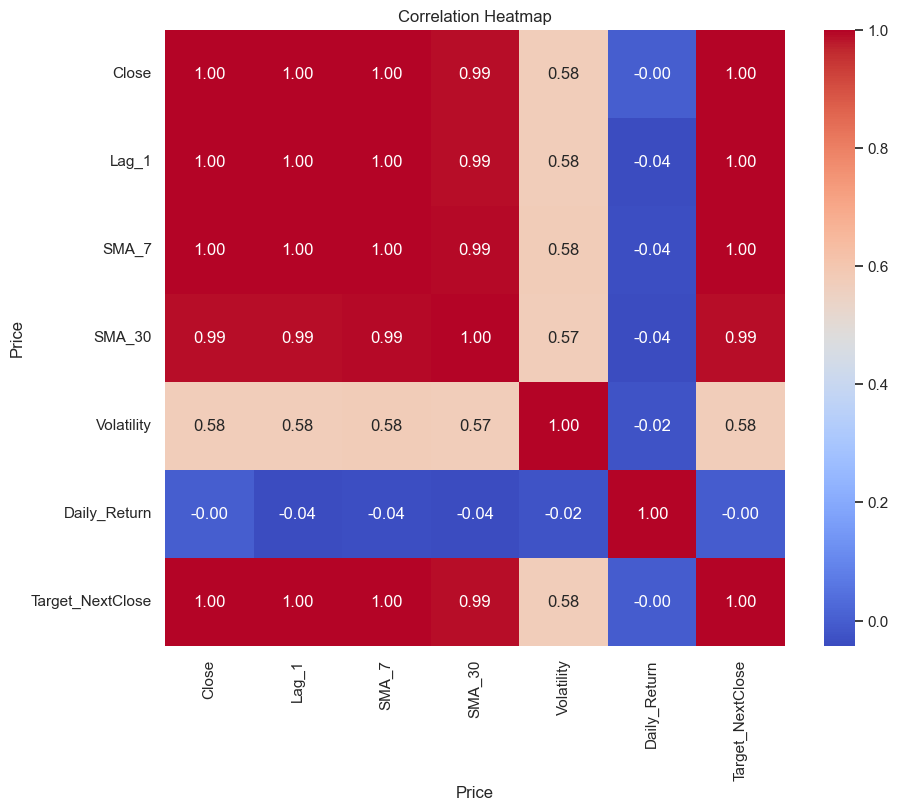

In [16]:
# Матрица на корелациите
features = ['Close', 'Lag_1', 'SMA_7', 'SMA_30', 'Volatility', 'Daily_Return', 'Target_NextClose']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

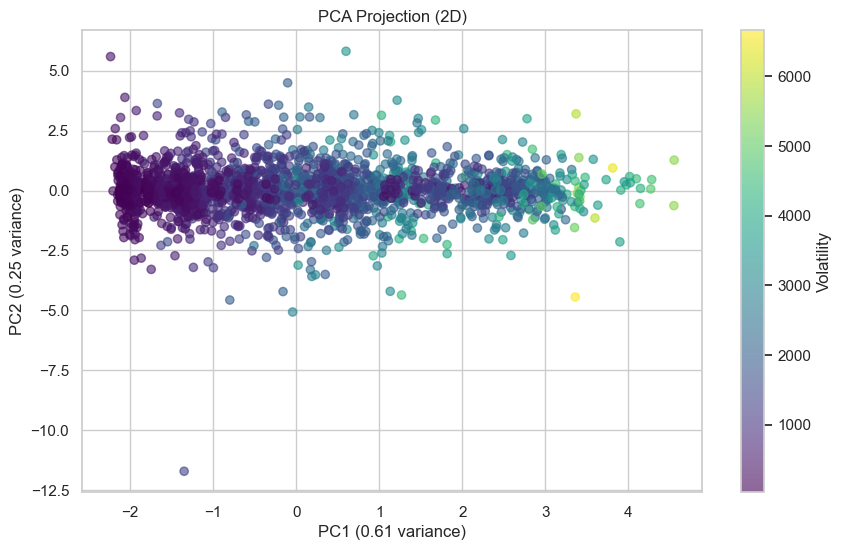

In [17]:
# Използваме PCA, за да видим дали данните се групират в клъстери (напр. "Спокоен пазар" vs "Криза")

# 1. Избираме само Features (без Target)
X_features = ['Close', 'Volatility', 'Daily_Return', 'SMA_7']
x = df[X_features].values

# 2. Скалиране (Задължително за PCA)
x_scaled = StandardScaler().fit_transform(x)

# 3. PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# 4. Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df['Volatility'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Volatility')
plt.title('PCA Projection (2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f} variance)')
plt.show()

### Анализ на Data Leakage и Избор на Признаци

#### 1. Идентифициране на Data Leakage (Критерий 5)
При анализа на корелациите забелязваме следното:
*   **Close vs Target (0.99):** Текущата цена има почти перфектна корелация с цената утре. Това **НЕ е leakage** в контекста на времевите редове (Auto-regressive property). Това е очаквано поведение.
*   **SMA_7 vs Target (0.99):** Също много висока корелация.
*   **Риск от Leakage:** Би имало изтичане, ако използваме признаци като `High_Next_Day` или `Volume_Next_Day`. В текущия набор всички признаци са базирани на **минало време** (t, t-1, t-7), следователно **Data Leakage няма**.

#### 2. Предложение за Feature Selection (Критерий 6)

| Признак | Статус | Аргументация |
|:---|:---|:---|
| **Close / Lag_1** | ✅ Включи | Основен носител на информация. Най-силният предиктор. |
| **SMA_7** | ✅ Включи | Помага за изглаждане на шума (Trend detection). |
| **SMA_30** | ❌ Изключи | Твърде висока мултиколинеарност с SMA_7 (0.99). Носи същата информация, но със закъснение. Излишна сложност. |
| **Volatility** | ✅ Включи | PCA анализът показва, че волатилността разделя данните на различни клъстери. Важна за засичане на аномалии. |
| **Daily_Return** | ✅ Включи | Стационарен признак (осцилира около 0), помага на LSTM да учи промените, а не само абсолютните стойности. |
| **Date** | ❌ Изключи | Невронната мрежа не разбира календарни дати. Ще бъде заменена от индекса на прозореца. |